In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("/content/Subscription_Service_Dataset.csv")

In [ ]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Unnamed: 21,AccountAge.1,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,42,11.321950,475.521914,Basic,Electronic check,Yes,Movies,Yes,Tablet,0.386852,...,15,No,No,LOHRYYC9E8,0,NaN,MonthlyCharges,NaN,NaN,Consolidated unique important features: ['Devi...
1,95,12.810915,1217.036887,Standard,Electronic check,Yes,TV Shows,No,Mobile,37.123000,...,8,No,NaN,RIH7RFEZCS,0,NaN,TotalCharges,NaN,NaN,NaN
2,6,NaN,91.583304,Standard,Credit card,Yes,TV Shows,No,Tablet,30.716944,...,14,No,Yes,JB5J8X2UY1,1,NaN,SubscriptionType,ok,NaN,NaN
3,54,17.917819,967.562224,Basic,NaN,Yes,Movies,No,Mobile,2.495373,...,12,No,NaN,Z4GZJIB90P,0,NaN,PaymentMethod,ok,NaN,NaN
4,27,NaN,339.057244,Basic,Mailed check,No,TV Shows,No,Mobile,39.936910,...,18,No,NaN,B3BDJTW0L9,0,NaN,PaperlessBilling,ok,NaN,NaN


In [ ]:
df.isnull().sum()

,0
AccountAge,0
MonthlyCharges,204
TotalCharges,186
SubscriptionType,50
PaymentMethod,223
PaperlessBilling,0
ContentType,0
MultiDeviceAccess,0
DeviceRegistered,76
ViewingHoursPerWeek,0


In [ ]:
df.drop(columns=["Unnamed: 21", "AccountAge.1", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25","SubtitlesEnabled", "Churn"], inplace = True)

In [ ]:
df.isnull().sum()

,0
AccountAge,0
MonthlyCharges,204
TotalCharges,186
SubscriptionType,50
PaymentMethod,223
PaperlessBilling,0
ContentType,0
MultiDeviceAccess,0
DeviceRegistered,76
ViewingHoursPerWeek,0


In [ ]:
for col in ['MonthlyCharges', 'TotalCharges', 'UserRating']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

for col in ['PaymentMethod', 'DeviceRegistered', 'GenrePreference', 'Gender', 'SubscriptionType']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
CustomerID                  0
dtype: int64


In [ ]:
df['CrossSell_Target'] = 'No'

condition_cross_sell = (
    (df['ViewingHoursPerWeek'] >= 30) |
    (df['ContentDownloadsPerMonth'] >= 35) |
    (df['WatchlistSize'] >= 18)
)

df.loc[condition_cross_sell, 'CrossSell_Target'] = 'Yes'

In [ ]:
df['Upgrade_Target'] = 'No'

condition_upgrade = (
    (df['MonthlyCharges'] >= 12) &
    (
        (df['ViewingHoursPerWeek'] >= 21) |
        (df['AverageViewingDuration'] >= 89)|
        (df['UserRating'] >= 3.5)
    ) &
    (df['AccountAge'] >= 55)
)

df.loc[condition_upgrade, 'Upgrade_Target'] = 'Yes'

In [ ]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,CustomerID,CrossSell_Target,Upgrade_Target
0,42,11.321950,475.521914,Basic,Electronic check,Yes,Movies,Yes,Tablet,0.386852,...,25,Comedy,3.489465,7,Female,15,No,LOHRYYC9E8,No,No
1,95,12.810915,1217.036887,Standard,Electronic check,Yes,TV Shows,No,Mobile,37.123000,...,21,Comedy,2.251860,3,Male,8,No,RIH7RFEZCS,Yes,Yes
2,6,12.328262,91.583304,Standard,Credit card,Yes,TV Shows,No,Tablet,30.716944,...,29,Fantasy,2.923945,4,Male,14,No,JB5J8X2UY1,Yes,No
3,54,17.917819,967.562224,Basic,Credit card,Yes,Movies,No,Mobile,2.495373,...,45,Drama,1.275004,3,Male,12,No,Z4GZJIB90P,Yes,No
4,27,12.328262,339.057244,Basic,Mailed check,No,TV Shows,No,Mobile,39.936910,...,44,Comedy,3.236230,4,Female,18,No,B3BDJTW0L9,Yes,No


In [ ]:
print(df['Upgrade_Target'].value_counts())

Upgrade_Target
No     719
Yes    244
Name: count, dtype: int64


In [ ]:
print(df['CrossSell_Target'].value_counts())

CrossSell_Target
Yes    587
No     376
Name: count, dtype: int64


In [ ]:
df['CrossSell_Target'].value_counts(normalize=True) * 100
df['Upgrade_Target'].value_counts(normalize=True) * 100

,proportion
Upgrade_Target,
No,74.662513
Yes,25.337487


In [ ]:
pd.crosstab(df['CrossSell_Target'], df['Upgrade_Target'])

Upgrade_Target,No,Yes
CrossSell_Target,,
No,290,86
Yes,429,158


In [ ]:
cat_columns = df.select_dtypes(include=["object"]).columns.to_list()
num_columns  = df.select_dtypes(include=["int64","float64"]).columns.to_list()

In [ ]:
cat_columns

['SubscriptionType',
 'PaymentMethod',
 'PaperlessBilling',
 'ContentType',
 'MultiDeviceAccess',
 'DeviceRegistered',
 'GenrePreference',
 'Gender',
 'ParentalControl',
 'CustomerID',
 'CrossSell_Target',
 'Upgrade_Target']

In [ ]:
num_columns

['AccountAge',
 'MonthlyCharges',
 'TotalCharges',
 'ViewingHoursPerWeek',
 'AverageViewingDuration',
 'ContentDownloadsPerMonth',
 'UserRating',
 'SupportTicketsPerMonth',
 'WatchlistSize']

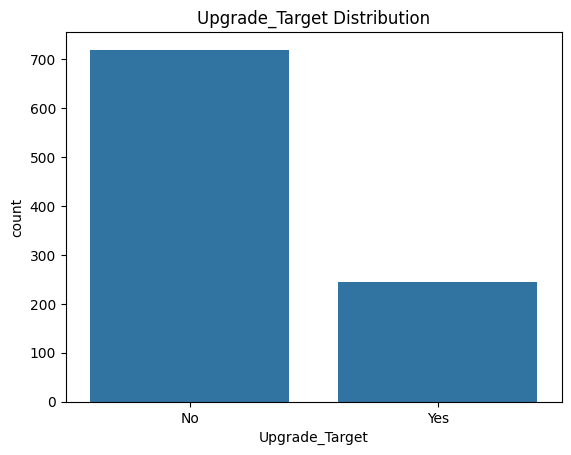

In [ ]:
sns.countplot(df, x="Upgrade_Target")
plt.title("Upgrade_Target Distribution")
plt.show()

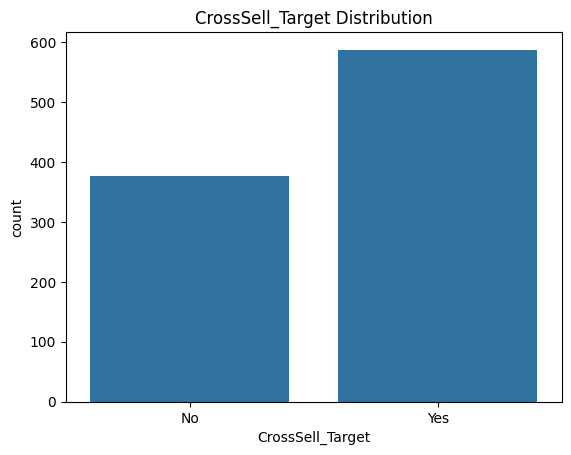

In [ ]:
sns.countplot(df, x="CrossSell_Target")
plt.title("CrossSell_Target Distribution")
plt.show()

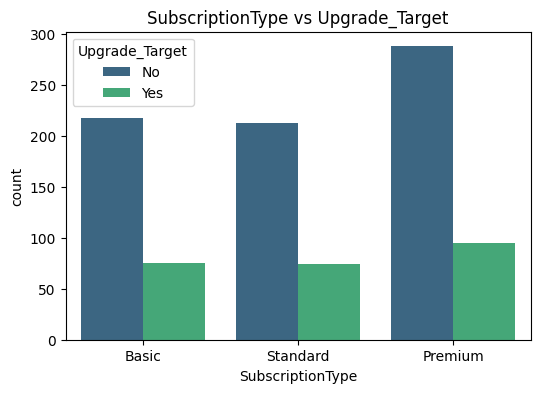

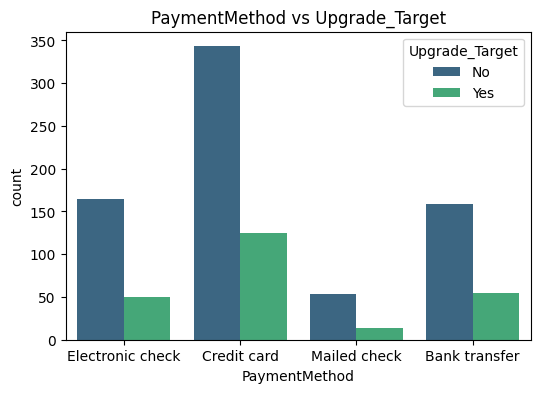

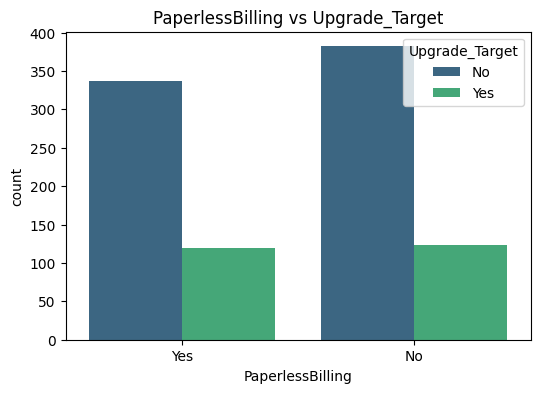

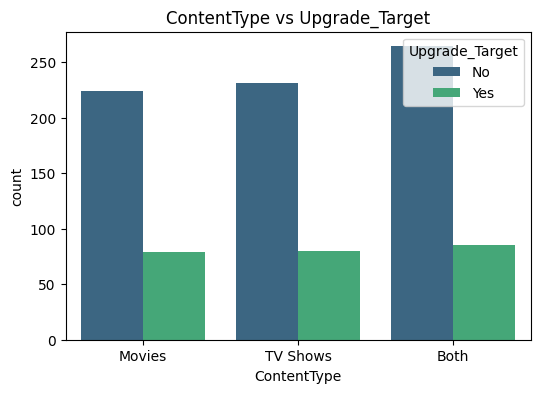

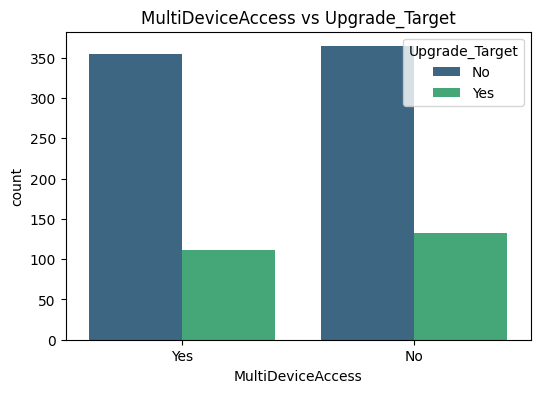

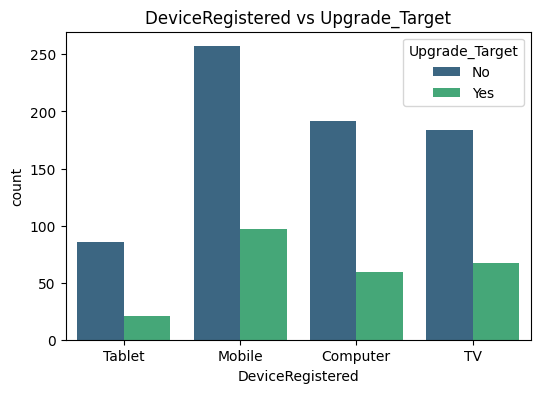

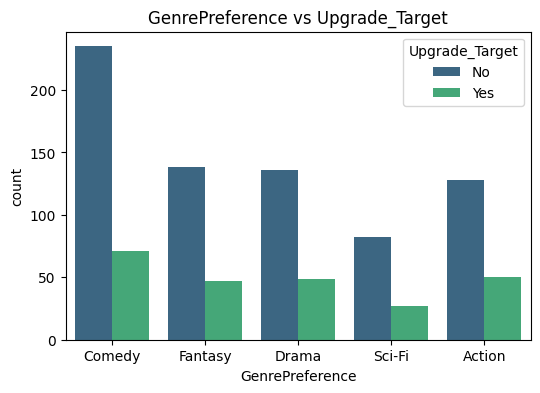

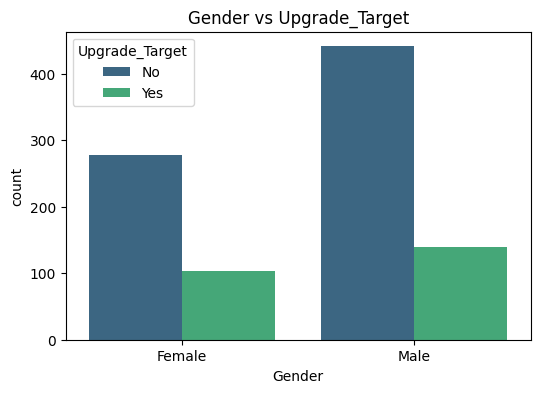

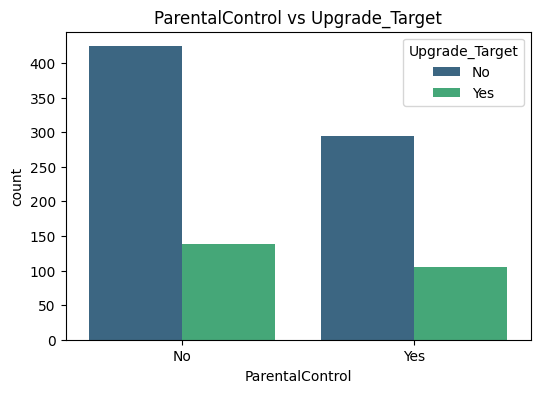

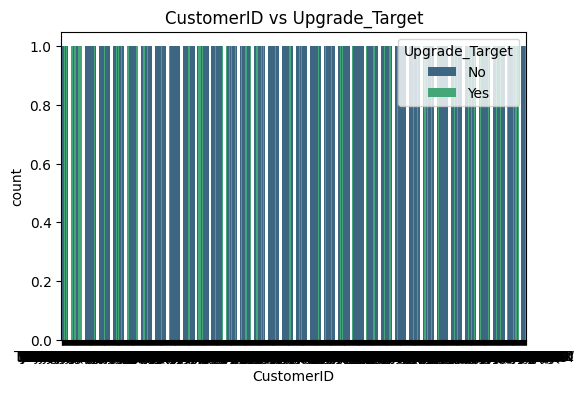

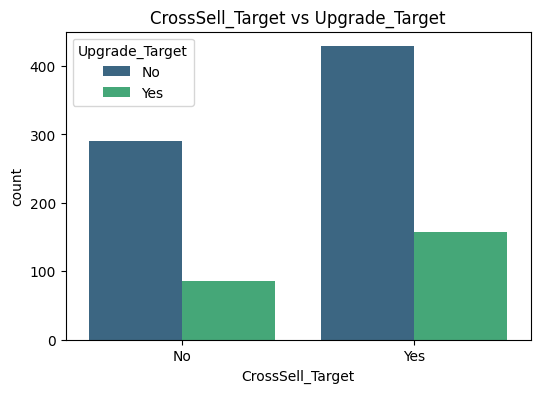

In [ ]:
for col in cat_columns[0:-1]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Upgrade_Target', data=df, palette='viridis')
    plt.title(f'{col} vs Upgrade_Target')
    plt.show()

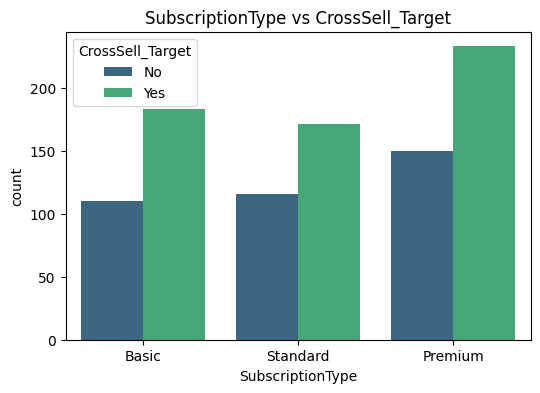

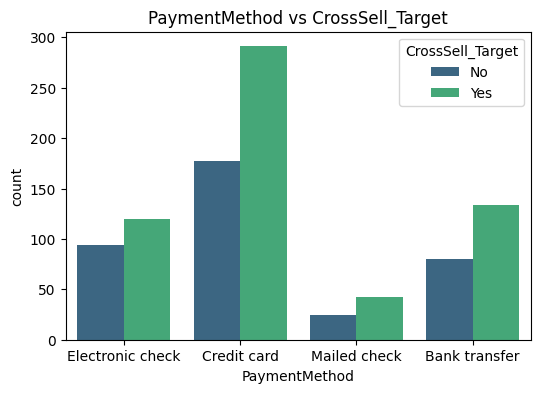

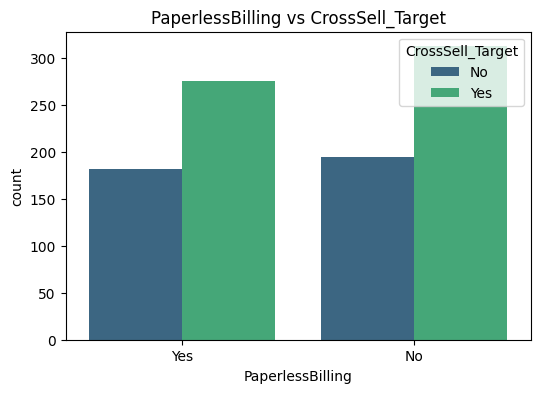

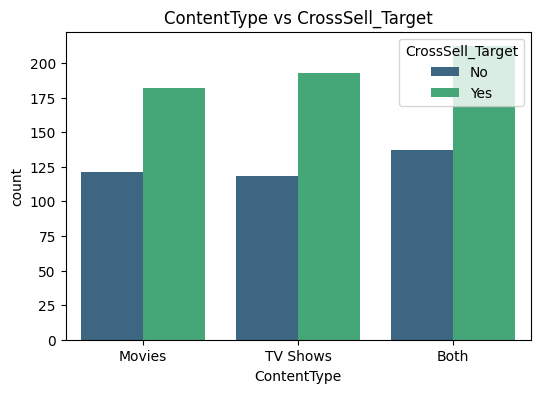

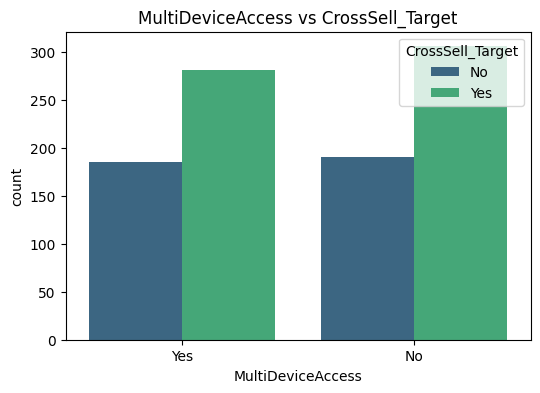

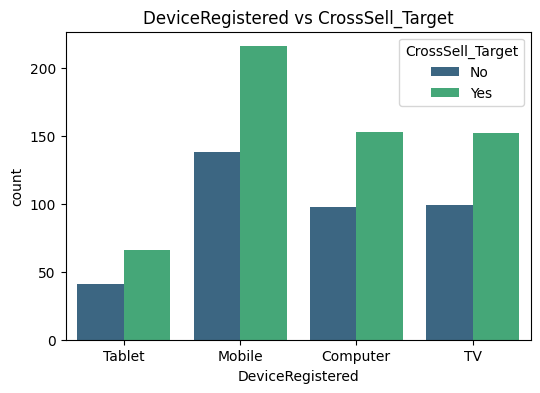

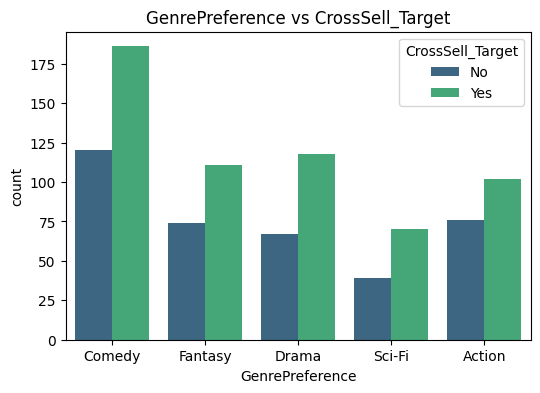

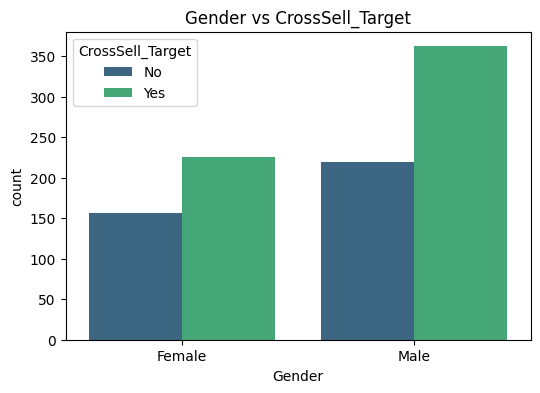

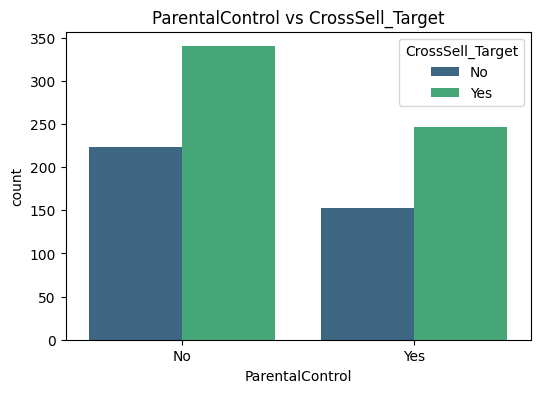

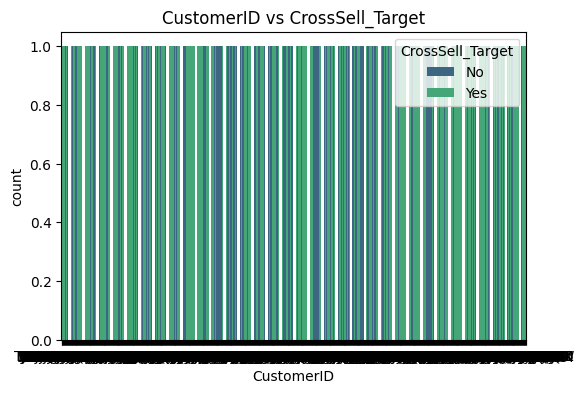

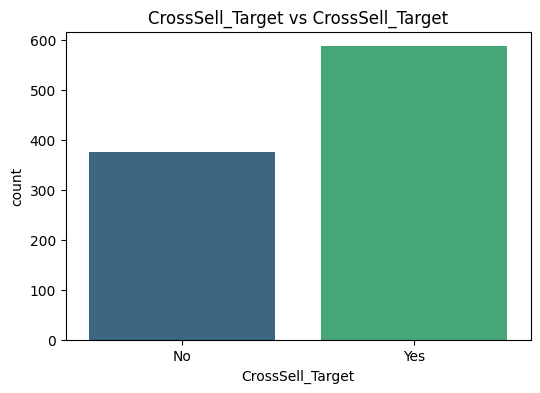

In [ ]:
for col in cat_columns[0:-1]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='CrossSell_Target', data=df, palette='viridis')
    plt.title(f'{col} vs CrossSell_Target')
    plt.show()

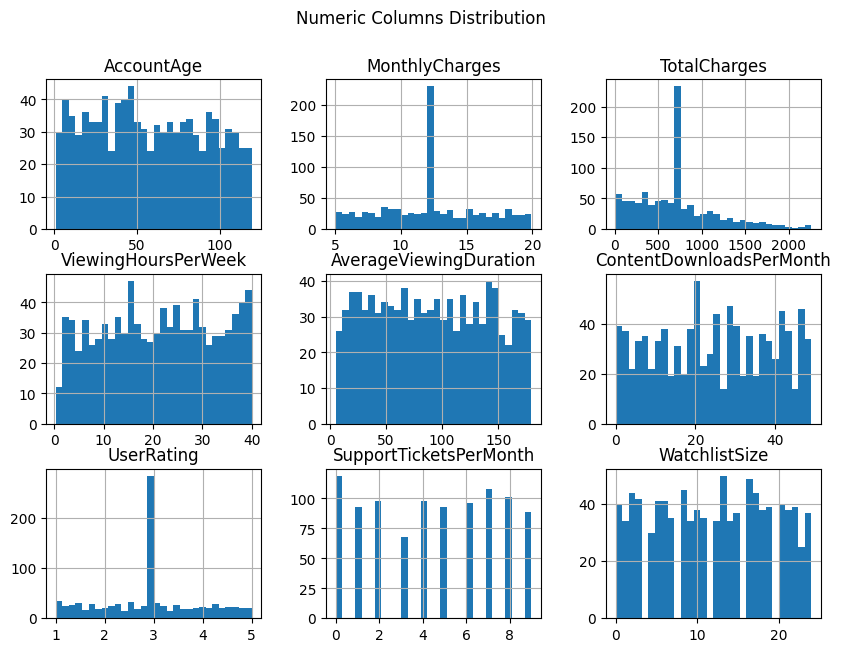

In [ ]:
df[num_columns].hist(bins=30, figsize=(10,7))
plt.suptitle("Numeric Columns Distribution")
plt.show()

In [ ]:
features_for_X = [
    'TotalCharges',
    'SubscriptionType',
    'PaymentMethod',
    'PaperlessBilling',
    'DeviceRegistered',
    'Gender',
    'ParentalControl',
    'SupportTicketsPerMonth',
    'MultiDeviceAccess',
    'GenrePreference',
    'ContentType'
]

X = df[features_for_X]

print("Final feature list in X:")
print(X.columns.to_list())

Final feature list in X:
['TotalCharges', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'DeviceRegistered', 'Gender', 'ParentalControl', 'SupportTicketsPerMonth', 'MultiDeviceAccess', 'GenrePreference', 'ContentType']


## Prepare data for CrossSell_Target

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
categorical_features_X = X.select_dtypes(include=['object']).columns
numerical_features_X = X.select_dtypes(include=['int64', 'float64']).columns

X_encoded = pd.get_dummies(X, columns=categorical_features_X, drop_first=True)

y_cross_sell = df['CrossSell_Target']
le = LabelEncoder()
y_cross_sell_encoded = le.fit_transform(y_cross_sell)

X_train_cross_sell, X_test_cross_sell, y_train_cross_sell, y_test_cross_sell = train_test_split(
    X_encoded, y_cross_sell_encoded, test_size=0.2, random_state=42, stratify=y_cross_sell_encoded
)


scaler = StandardScaler()
X_train_cross_sell[numerical_features_X] = scaler.fit_transform(X_train_cross_sell[numerical_features_X])
X_test_cross_sell[numerical_features_X] = scaler.transform(X_test_cross_sell[numerical_features_X])

print("Shapes for CrossSell_Target data:")
print(f"X_train_cross_sell shape: {X_train_cross_sell.shape}")
print(f"X_test_cross_sell shape: {X_test_cross_sell.shape}")
print(f"y_train_cross_sell shape: {y_train_cross_sell.shape}")
print(f"y_test_cross_sell shape: {y_test_cross_sell.shape}")

Shapes for CrossSell_Target data:
X_train_cross_sell shape: (770, 20)
X_test_cross_sell shape: (193, 20)
y_train_cross_sell shape: (770,)
y_test_cross_sell shape: (193,)


## Prepare data for Upgrade_Target

In [ ]:
y_upgrade = df['Upgrade_Target']
y_upgrade_encoded = le.fit_transform(y_upgrade)

X_train_upgrade, X_test_upgrade, y_train_upgrade, y_test_upgrade = train_test_split(
    X_encoded, y_upgrade_encoded, test_size=0.2, random_state=42, stratify=y_upgrade_encoded
)

X_train_upgrade[numerical_features_X] = scaler.fit_transform(X_train_upgrade[numerical_features_X])
X_test_upgrade[numerical_features_X] = scaler.transform(X_test_upgrade[numerical_features_X])

print("\nShapes for Upgrade_Target data:")
print(f"X_train_upgrade shape: {X_train_upgrade.shape}")
print(f"X_test_upgrade shape: {X_test_upgrade.shape}")
print(f"y_train_upgrade shape: {y_train_upgrade.shape}")
print(f"y_test_upgrade shape: {y_test_upgrade.shape}")


Shapes for Upgrade_Target data:
X_train_upgrade shape: (770, 20)
X_test_upgrade shape: (193, 20)
y_train_upgrade shape: (770,)
y_test_upgrade shape: (193,)


In [ ]:
import numpy as np

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_X.to_list())
    ],
    remainder='passthrough'
)

model_pipeline_upgrade = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

print("--- Training and Evaluating Upgrade Model (Logistic Regression) ---")
roc_auc_scores_upgrade = cross_val_score(model_pipeline_upgrade, X_encoded, y_upgrade_encoded,
                                           cv=skf, scoring='roc_auc')

print(f"\nMean ROC-AUC for Upgrade Model: {np.mean(roc_auc_scores_upgrade):.4f}")
print(f"Standard Deviation of ROC-AUC for Upgrade Model: {np.std(roc_auc_scores_upgrade):.4f}")

cv_predictions_upgrade = cross_val_predict(model_pipeline_upgrade, X_encoded, y_upgrade_encoded,
                                             cv=skf, method='predict')

if 'le' not in globals() or not hasattr(le, 'classes_') or len(le.classes_) == 0 or not np.array_equal(le.classes_, df['Upgrade_Target'].unique()):
    le = LabelEncoder()
    le.fit(df['Upgrade_Target'])

cm_upgrade = confusion_matrix(y_upgrade_encoded, cv_predictions_upgrade)
print("\nConfusion Matrix for Upgrade Model:")
print(cm_upgrade)

cr_upgrade = classification_report(y_upgrade_encoded, cv_predictions_upgrade, target_names=le.classes_)
print("\nClassification Report for Upgrade Model:")
print(cr_upgrade)

--- Training and Evaluating Upgrade Model (Logistic Regression) ---

Mean ROC-AUC for Upgrade Model: 0.8564
Standard Deviation of ROC-AUC for Upgrade Model: 0.0232

Confusion Matrix for Upgrade Model:
[[676  43]
 [121 123]]

Classification Report for Upgrade Model:
              precision    recall  f1-score   support

          No       0.85      0.94      0.89       719
         Yes       0.74      0.50      0.60       244

    accuracy                           0.83       963
   macro avg       0.79      0.72      0.75       963
weighted avg       0.82      0.83      0.82       963



In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_X.to_list())
    ],
    remainder='passthrough'
)

model_pipeline_cross_sell_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


print("--- Training and Evaluating Cross-Sell Model (Random Forest) ---")


roc_auc_scores_cross_sell_rf = cross_val_score(
    model_pipeline_cross_sell_rf, X_encoded, y_cross_sell_encoded, cv=skf, scoring='roc_auc'
)

print(f"\nMean ROC-AUC (Cross-Sell Random Forest): {np.mean(roc_auc_scores_cross_sell_rf):.4f}")
print(f"Standard Deviation of ROC-AUC (Cross-Sell Random Forest): {np.std(roc_auc_scores_cross_sell_rf):.4f}")

cv_predictions_cross_sell_rf = cross_val_predict(
    model_pipeline_cross_sell_rf, X_encoded, y_cross_sell_encoded, cv=skf, method='predict'
)

conf_matrix_cross_sell_rf = confusion_matrix(y_cross_sell_encoded, cv_predictions_cross_sell_rf)
print("\nConfusion Matrix (Cross-Sell Random Forest):")
print(conf_matrix_cross_sell_rf)

class_report_cross_sell_rf = classification_report(
    y_cross_sell_encoded, cv_predictions_cross_sell_rf, target_names=le.classes_
)
print("\nClassification Report (Cross-Sell Random Forest):")
print(class_report_cross_sell_rf)

--- Training and Evaluating Cross-Sell Model (Random Forest) ---

Mean ROC-AUC (Cross-Sell Random Forest): 0.5287
Standard Deviation of ROC-AUC (Cross-Sell Random Forest): 0.0503

Confusion Matrix (Cross-Sell Random Forest):
[[ 75 301]
 [107 480]]

Classification Report (Cross-Sell Random Forest):
              precision    recall  f1-score   support

          No       0.41      0.20      0.27       376
         Yes       0.61      0.82      0.70       587

    accuracy                           0.58       963
   macro avg       0.51      0.51      0.49       963
weighted avg       0.54      0.58      0.53       963



In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np


model_pipeline_upgrade_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("--- Training and Evaluating Upgrade Model (Random Forest) ---")

roc_auc_scores_upgrade_rf = cross_val_score(
    model_pipeline_upgrade_rf, X_encoded, y_upgrade_encoded, cv=skf, scoring='roc_auc'
)

print(f"\nMean ROC-AUC (Upgrade Random Forest): {np.mean(roc_auc_scores_upgrade_rf):.4f}")
print(f"Standard Deviation of ROC-AUC (Upgrade Random Forest): {np.std(roc_auc_scores_upgrade_rf):.4f}")

cv_predictions_upgrade_rf = cross_val_predict(
    model_pipeline_upgrade_rf, X_encoded, y_upgrade_encoded, cv=skf, method='predict'
)

if 'le' not in globals() or not hasattr(le, 'classes_') or not np.array_equal(le.classes_, df['Upgrade_Target'].unique()):
    le = LabelEncoder()
    le.fit(df['Upgrade_Target'])

conf_matrix_upgrade_rf = confusion_matrix(y_upgrade_encoded, cv_predictions_upgrade_rf)
print("\nConfusion Matrix (Upgrade Random Forest):")
print(conf_matrix_upgrade_rf)

class_report_upgrade_rf = classification_report(
    y_upgrade_encoded, cv_predictions_upgrade_rf, target_names=le.classes_
)
print("\nClassification Report (Upgrade Random Forest):")
print(class_report_upgrade_rf)


--- Training and Evaluating Upgrade Model (Random Forest) ---

Mean ROC-AUC (Upgrade Random Forest): 0.8296
Standard Deviation of ROC-AUC (Upgrade Random Forest): 0.0278

Confusion Matrix (Upgrade Random Forest):
[[662  57]
 [125 119]]

Classification Report (Upgrade Random Forest):
              precision    recall  f1-score   support

          No       0.84      0.92      0.88       719
         Yes       0.68      0.49      0.57       244

    accuracy                           0.81       963
   macro avg       0.76      0.70      0.72       963
weighted avg       0.80      0.81      0.80       963



In [ ]:
from xgboost import XGBClassifier
import numpy as np

model_pipeline_cross_sell_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])


print("--- Training and Evaluating Cross-Sell Model (XGBoost) ---")

roc_auc_scores_cross_sell_xgb = cross_val_score(
    model_pipeline_cross_sell_xgb, X_encoded, y_cross_sell_encoded, cv=skf, scoring='roc_auc'
)

print(f"\nMean ROC-AUC (Cross-Sell XGBoost): {np.mean(roc_auc_scores_cross_sell_xgb):.4f}")
print(f"Standard Deviation of ROC-AUC (Cross-Sell XGBoost): {np.std(roc_auc_scores_cross_sell_xgb):.4f}")

cv_predictions_cross_sell_xgb = cross_val_predict(
    model_pipeline_cross_sell_xgb, X_encoded, y_cross_sell_encoded, cv=skf, method='predict'
)

conf_matrix_cross_sell_xgb = confusion_matrix(y_cross_sell_encoded, cv_predictions_cross_sell_xgb)
print("\nConfusion Matrix (Cross-Sell XGBoost):")
print(conf_matrix_cross_sell_xgb)

class_report_cross_sell_xgb = classification_report(
    y_cross_sell_encoded, cv_predictions_cross_sell_xgb, target_names=le.classes_
)
print("\nClassification Report (Cross-Sell XGBoost):")
print(class_report_cross_sell_xgb)

--- Training and Evaluating Cross-Sell Model (XGBoost) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Mean ROC-AUC (Cross-Sell XGBoost): 0.4672
Standard Deviation of ROC-AUC (Cross-Sell XGBoost): 0.0359


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix (Cross-Sell XGBoost):
[[107 269]
 [195 392]]

Classification Report (Cross-Sell XGBoost):
              precision    recall  f1-score   support

          No       0.35      0.28      0.32       376
         Yes       0.59      0.67      0.63       587

    accuracy                           0.52       963
   macro avg       0.47      0.48      0.47       963
weighted avg       0.50      0.52      0.51       963



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from xgboost import XGBClassifier
import numpy as np
model_pipeline_cross_sell_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])


print("--- Training and Evaluating Cross-Sell Model (XGBoost) ---")

roc_auc_scores_cross_sell_xgb = cross_val_score(
    model_pipeline_cross_sell_xgb, X_encoded, y_cross_sell_encoded, cv=skf, scoring='roc_auc'
)

print(f"\nMean ROC-AUC (Cross-Sell XGBoost): {np.mean(roc_auc_scores_cross_sell_xgb):.4f}")
print(f"Standard Deviation of ROC-AUC (Cross-Sell XGBoost): {np.std(roc_auc_scores_cross_sell_xgb):.4f}")

cv_predictions_cross_sell_xgb = cross_val_predict(
    model_pipeline_cross_sell_xgb, X_encoded, y_cross_sell_encoded, cv=skf, method='predict'
)

conf_matrix_cross_sell_xgb = confusion_matrix(y_cross_sell_encoded, cv_predictions_cross_sell_xgb)
print("\nConfusion Matrix (Cross-Sell XGBoost):")
print(conf_matrix_cross_sell_xgb)

class_report_cross_sell_xgb = classification_report(
    y_cross_sell_encoded, cv_predictions_cross_sell_xgb, target_names=le.classes_
)
print("\nClassification Report (Cross-Sell XGBoost):")
print(class_report_cross_sell_xgb)

--- Training and Evaluating Cross-Sell Model (XGBoost) ---

Mean ROC-AUC (Cross-Sell XGBoost): 0.4672
Standard Deviation of ROC-AUC (Cross-Sell XGBoost): 0.0359

Confusion Matrix (Cross-Sell XGBoost):
[[107 269]
 [195 392]]

Classification Report (Cross-Sell XGBoost):
              precision    recall  f1-score   support

          No       0.35      0.28      0.32       376
         Yes       0.59      0.67      0.63       587

    accuracy                           0.52       963
   macro avg       0.47      0.48      0.47       963
weighted avg       0.50      0.52      0.51       963



In [ ]:
from xgboost import XGBClassifier
import numpy as np

model_pipeline_upgrade_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

print("--- Training and Evaluating Upgrade Model (XGBoost) ---")

roc_auc_scores_upgrade_xgb = cross_val_score(
    model_pipeline_upgrade_xgb, X_encoded, y_upgrade_encoded, cv=skf, scoring='roc_auc'
)

print(f"\nMean ROC-AUC (Upgrade XGBoost): {np.mean(roc_auc_scores_upgrade_xgb):.4f}")
print(f"Standard Deviation of ROC-AUC (Upgrade XGBoost): {np.std(roc_auc_scores_upgrade_xgb):.4f}")

cv_predictions_upgrade_xgb = cross_val_predict(
    model_pipeline_upgrade_xgb, X_encoded, y_upgrade_encoded, cv=skf, method='predict'
)

if 'le' not in globals() or not hasattr(le, 'classes_') or not np.array_equal(le.classes_, df['Upgrade_Target'].unique()):
    le = LabelEncoder()
    le.fit(df['Upgrade_Target'])
conf_matrix_upgrade_xgb = confusion_matrix(y_upgrade_encoded, cv_predictions_upgrade_xgb)
print("\nConfusion Matrix (Upgrade XGBoost):")
print(conf_matrix_upgrade_xgb)

class_report_upgrade_xgb = classification_report(
    y_upgrade_encoded, cv_predictions_upgrade_xgb, target_names=le.classes_
)
print("\nClassification Report (Upgrade XGBoost):")
print(class_report_upgrade_xgb)

--- Training and Evaluating Upgrade Model (XGBoost) ---

Mean ROC-AUC (Upgrade XGBoost): 0.8200
Standard Deviation of ROC-AUC (Upgrade XGBoost): 0.0279

Confusion Matrix (Upgrade XGBoost):
[[627  92]
 [114 130]]

Classification Report (Upgrade XGBoost):
              precision    recall  f1-score   support

          No       0.85      0.87      0.86       719
         Yes       0.59      0.53      0.56       244

    accuracy                           0.79       963
   macro avg       0.72      0.70      0.71       963
weighted avg       0.78      0.79      0.78       963



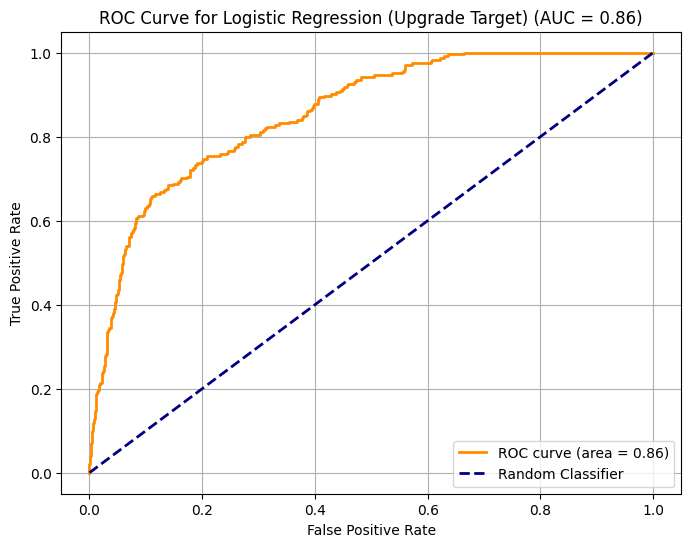

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba_upgrade = cross_val_predict(
    model_pipeline_upgrade, X_encoded, y_upgrade_encoded, cv=skf, method='predict_proba'
)[:, 1]

fpr_upgrade, tpr_upgrade, thresholds_upgrade = roc_curve(y_upgrade_encoded, y_pred_proba_upgrade)

roc_auc_upgrade = roc_auc_score(y_upgrade_encoded, y_pred_proba_upgrade)

plt.figure(figsize=(8, 6))
plt.plot(fpr_upgrade, tpr_upgrade, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc_upgrade:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Logistic Regression (Upgrade Target) (AUC = {roc_auc_upgrade:.2f})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

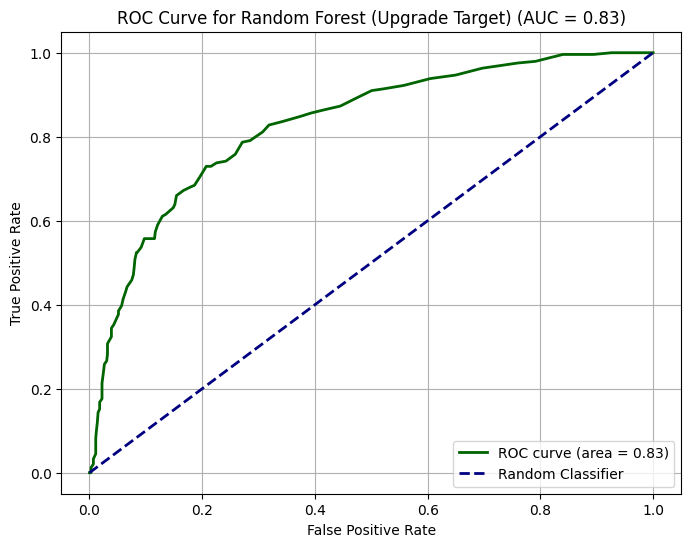

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba_upgrade_rf = cross_val_predict(
    model_pipeline_upgrade_rf, X_encoded, y_upgrade_encoded, cv=skf, method='predict_proba'
)[:, 1]

fpr_upgrade_rf, tpr_upgrade_rf, thresholds_upgrade_rf = roc_curve(y_upgrade_encoded, y_pred_proba_upgrade_rf)

roc_auc_upgrade_rf = roc_auc_score(y_upgrade_encoded, y_pred_proba_upgrade_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_upgrade_rf, tpr_upgrade_rf, color='darkgreen', lw=2,
         label=f'ROC curve (area = {roc_auc_upgrade_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Random Forest (Upgrade Target) (AUC = {roc_auc_upgrade_rf:.2f})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

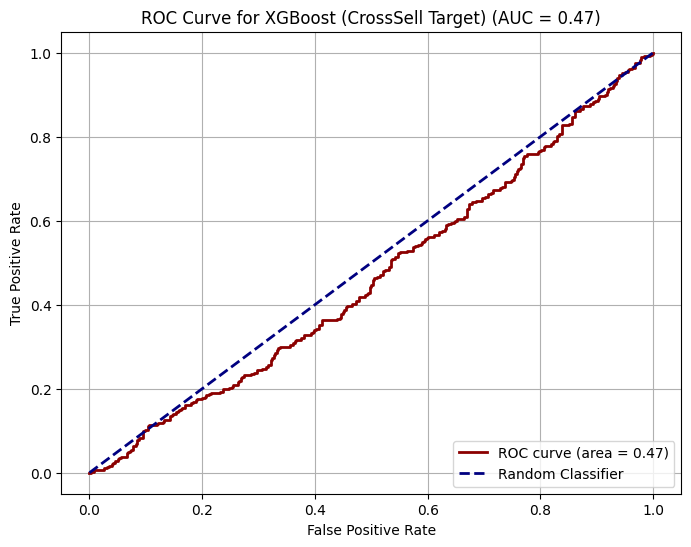

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_pred_proba_cross_sell_xgb = cross_val_predict(
    model_pipeline_cross_sell_xgb, X_encoded, y_cross_sell_encoded, cv=skf, method='predict_proba'
)[:, 1]


fpr_cross_sell_xgb, tpr_cross_sell_xgb, thresholds_cross_sell_xgb = roc_curve(y_cross_sell_encoded, y_pred_proba_cross_sell_xgb)


roc_auc_cross_sell_xgb_plot = roc_auc_score(y_cross_sell_encoded, y_pred_proba_cross_sell_xgb)


plt.figure(figsize=(8, 6))
plt.plot(fpr_cross_sell_xgb, tpr_cross_sell_xgb, color='darkred', lw=2,
         label=f'ROC curve (area = {roc_auc_cross_sell_xgb_plot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for XGBoost (CrossSell Target) (AUC = {roc_auc_cross_sell_xgb_plot:.2f})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

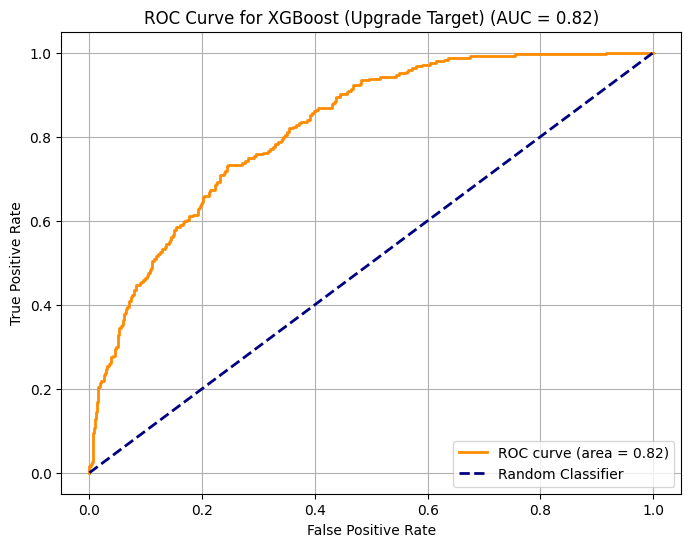

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_pred_proba_upgrade_xgb = cross_val_predict(
    model_pipeline_upgrade_xgb, X_encoded, y_upgrade_encoded, cv=skf, method='predict_proba'
)[:, 1]

fpr_upgrade_xgb, tpr_upgrade_xgb, thresholds_upgrade_xgb = roc_curve(y_upgrade_encoded, y_pred_proba_upgrade_xgb)


roc_auc_upgrade_xgb_plot = roc_auc_score(y_upgrade_encoded, y_pred_proba_upgrade_xgb)


plt.figure(figsize=(8, 6))
plt.plot(fpr_upgrade_xgb, tpr_upgrade_xgb, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc_upgrade_xgb_plot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for XGBoost (Upgrade Target) (AUC = {roc_auc_upgrade_xgb_plot:.2f})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

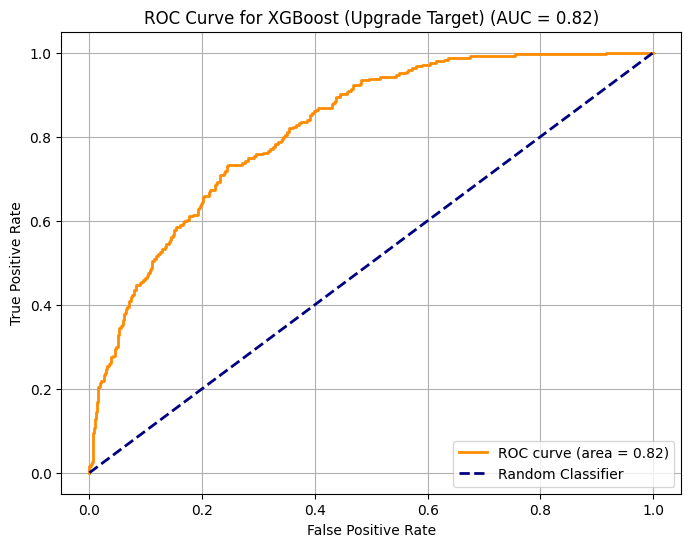

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_pred_proba_upgrade_xgb = cross_val_predict(
    model_pipeline_upgrade_xgb, X_encoded, y_upgrade_encoded, cv=skf, method='predict_proba'
)[:, 1]


fpr_upgrade_xgb, tpr_upgrade_xgb, thresholds_upgrade_xgb = roc_curve(y_upgrade_encoded, y_pred_proba_upgrade_xgb)


roc_auc_upgrade_xgb_plot = roc_auc_score(y_upgrade_encoded, y_pred_proba_upgrade_xgb)


plt.figure(figsize=(8, 6))
plt.plot(fpr_upgrade_xgb, tpr_upgrade_xgb, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc_upgrade_xgb_plot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for XGBoost (Upgrade Target) (AUC = {roc_auc_upgrade_xgb_plot:.2f})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
print("--- Logistic Regression Results for Cross-Sell Target ---")
print("\nClassification Report (Cross-Sell Logistic Regression):")
print(class_report_cross_sell)

--- Logistic Regression Results for Cross-Sell Target ---

Classification Report (Cross-Sell Logistic Regression):
              precision    recall  f1-score   support

          No       0.26      0.02      0.04       376
         Yes       0.60      0.96      0.74       587

    accuracy                           0.59       963
   macro avg       0.43      0.49      0.39       963
weighted avg       0.47      0.59      0.47       963



In [ ]:
print("--- Random Forest Results for Cross-Sell Target ---")
print("\nClassification Report (Cross-Sell Random Forest):")
print(class_report_cross_sell_rf)

--- Random Forest Results for Cross-Sell Target ---

Classification Report (Cross-Sell Random Forest):
              precision    recall  f1-score   support

          No       0.41      0.20      0.27       376
         Yes       0.61      0.82      0.70       587

    accuracy                           0.58       963
   macro avg       0.51      0.51      0.49       963
weighted avg       0.54      0.58      0.53       963



**Reasoning**:
To complete the task, I need to display the classification report for the XGBoost model on the `CrossSell_Target`. The `class_report_cross_sell_xgb` variable is available from previous executions.



In [ ]:
print("--- XGBoost Results for Cross-Sell Target ---")
print("\nClassification Report (Cross-Sell XGBoost):")
print(class_report_cross_sell_xgb)

--- XGBoost Results for Cross-Sell Target ---

Classification Report (Cross-Sell XGBoost):
              precision    recall  f1-score   support

          No       0.35      0.28      0.32       376
         Yes       0.59      0.67      0.63       587

    accuracy                           0.52       963
   macro avg       0.47      0.48      0.47       963
weighted avg       0.50      0.52      0.51       963



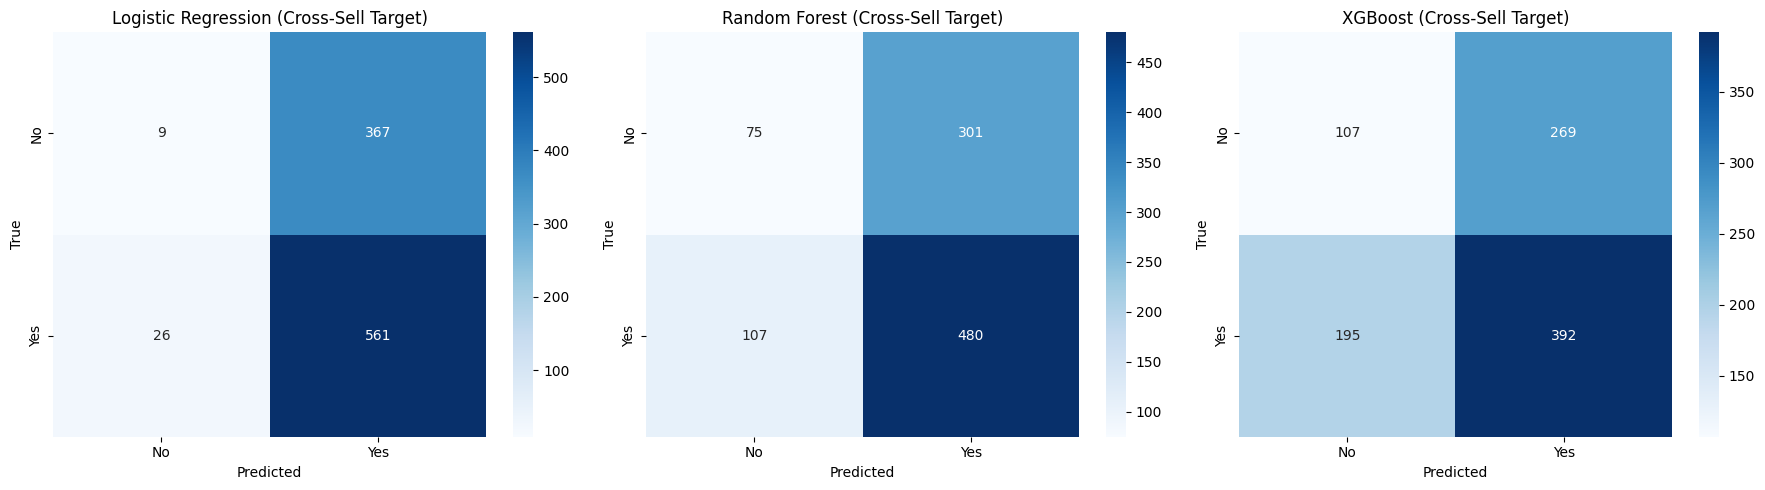

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.heatmap(conf_matrix_cross_sell, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression (Cross-Sell Target)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')


sns.heatmap(conf_matrix_cross_sell_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Random Forest (Cross-Sell Target)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')


sns.heatmap(conf_matrix_cross_sell_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[2])
axes[2].set_title('XGBoost (Cross-Sell Target)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')


plt.tight_layout()
plt.show()

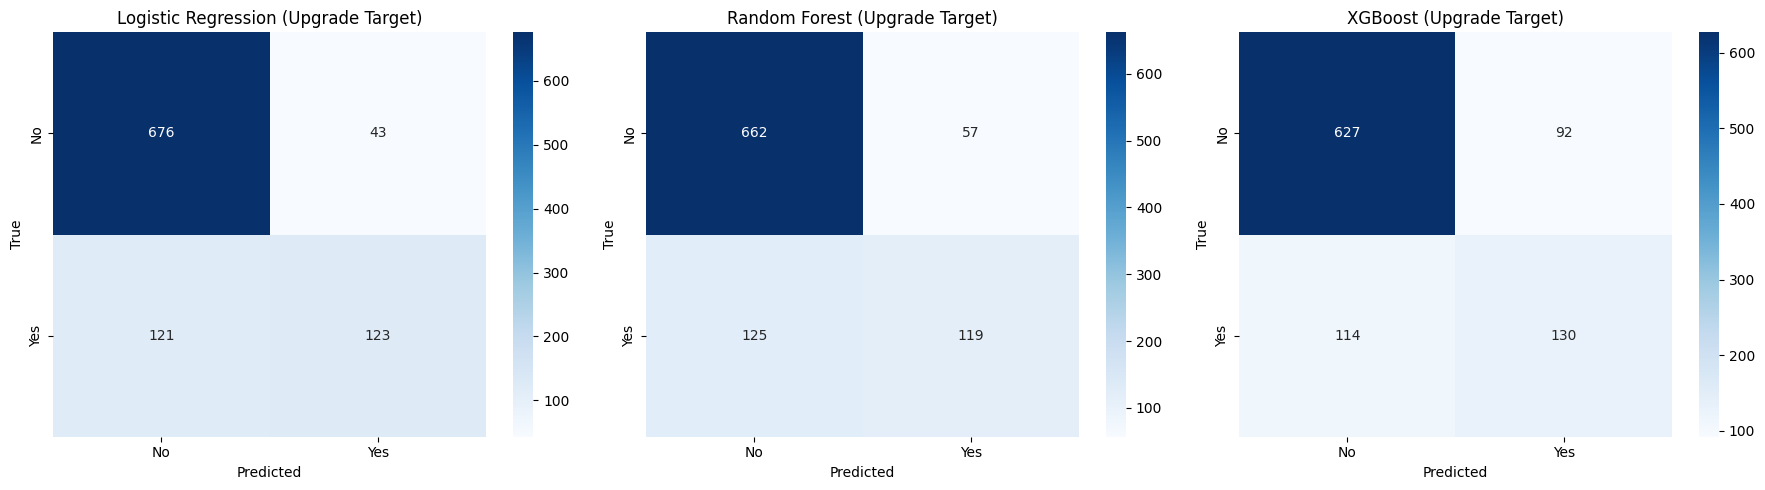

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_upgrade, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression (Upgrade Target)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(conf_matrix_upgrade_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Random Forest (Upgrade Target)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

sns.heatmap(conf_matrix_upgrade_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[2])
axes[2].set_title('XGBoost (Upgrade Target)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.show()